In [3]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torchvision import datasets
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch version:", torch.__version__)

Using device: cuda
Torch version: 2.5.1


In [ ]:
model_name = "facebook/convnext-base-224"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    "facebook/convnext-base-224",
    num_labels=2,
    use_safetensors=True,
    ignore_mismatched_sizes=True
)

model.to(device)

# my data was too small so i have to use this
for param in model.convnext.parameters():
    param.requires_grad = False

print("Backbone frozen ✅")

Some weights of ConvNextForImageClassification were not initialized from the model checkpoint at facebook/convnext-base-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 1024]) in the checkpoint and torch.Size([2, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Backbone frozen ✅


In [18]:
from torchvision.transforms import RandomHorizontalFlip, RandomRotation

train_transform = Compose([
    Resize((224, 224)),
    RandomHorizontalFlip(),
    RandomRotation(15),
    ToTensor(),
    Normalize(mean=processor.image_mean, std=processor.image_std)
])

val_transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=processor.image_mean, std=processor.image_std)
])

In [23]:
train_dataset = datasets.ImageFolder(
    "dataset/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "dataset/validation",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("Classes:", train_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Classes: ['ANI', 'ANT']
Training samples: 66
Validation samples: 22


In [24]:
optimizer = torch.optim.AdamW(
    model.classifier.parameters(),  # Only training the classification head
    lr=1e-4
)

criterion = torch.nn.CrossEntropyLoss()

print("Optimizer ready ✅")

Optimizer ready ✅


In [25]:
scaler = torch.cuda.amp.GradScaler()

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs.logits, dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_36464\2915946628.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_36464\2915946628.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/15 | Loss: 0.6853 | Train Acc: 0.5455 | Val Acc: 0.7273
Epoch 2/15 | Loss: 0.6707 | Train Acc: 0.6667 | Val Acc: 0.6818
Epoch 3/15 | Loss: 0.6497 | Train Acc: 0.6212 | Val Acc: 0.7727
Epoch 4/15 | Loss: 0.6343 | Train Acc: 0.6970 | Val Acc: 0.7727
Epoch 5/15 | Loss: 0.6232 | Train Acc: 0.6364 | Val Acc: 0.7727
Epoch 6/15 | Loss: 0.6033 | Train Acc: 0.6364 | Val Acc: 0.7727
Epoch 7/15 | Loss: 0.5852 | Train Acc: 0.6515 | Val Acc: 0.7273
Epoch 8/15 | Loss: 0.5758 | Train Acc: 0.6364 | Val Acc: 0.7273
Epoch 9/15 | Loss: 0.5737 | Train Acc: 0.7121 | Val Acc: 0.7273
Epoch 10/15 | Loss: 0.5816 | Train Acc: 0.6667 | Val Acc: 0.7273
Epoch 11/15 | Loss: 0.5738 | Train Acc: 0.7121 | Val Acc: 0.7273
Epoch 12/15 | Loss: 0.5390 | Train Acc: 0.7121 | Val Acc: 0.7727
Epoch 13/15 | Loss: 0.5599 | Train Acc: 0.7273 | Val Acc: 0.8182
Epoch 14/15 | Loss: 0.5379 | Train Acc: 0.7273 | Val Acc: 0.8182
Epoch 15/15 | Loss: 0.5448 | Train Acc: 0.7424 | Val Acc: 0.8182


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2739873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1804092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3585434].


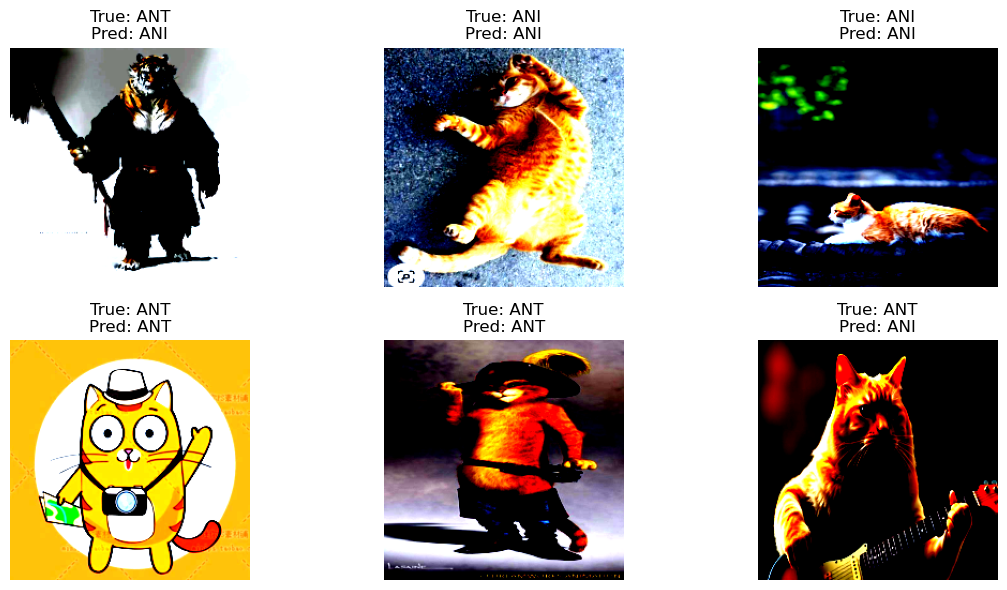

In [26]:
import matplotlib.pyplot as plt
import random

model.eval()

# 随机选 6 张 validation 图片
indices = random.sample(range(len(val_dataset)), 6)

plt.figure(figsize=(12,6))

for i, idx in enumerate(indices):
    img, label = val_dataset[idx]
    
    input_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output.logits, dim=1).item()
    
    plt.subplot(2,3,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"True: {val_dataset.classes[label]}\nPred: {val_dataset.classes[pred]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

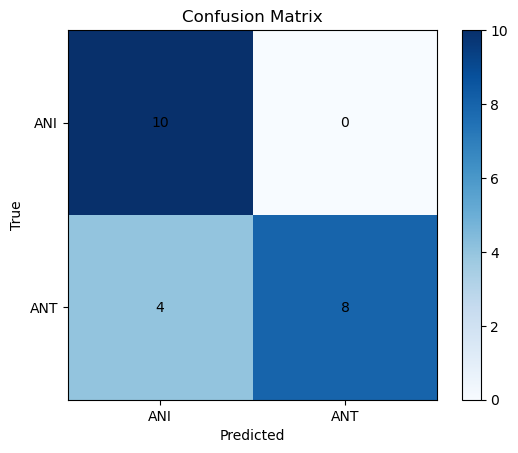

              precision    recall  f1-score   support

         ANI       0.71      1.00      0.83        10
         ANT       1.00      0.67      0.80        12

    accuracy                           0.82        22
   macro avg       0.86      0.83      0.82        22
weighted avg       0.87      0.82      0.82        22



In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(2), train_dataset.classes)
plt.yticks(range(2), train_dataset.classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))